In [28]:
import numpy as np
import pandas as pd

In [29]:
df = pd.read_csv(r"C:\Users\User\Documents\fintech dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [30]:
df.shape

(1048575, 11)

In [31]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00,0.0


In [32]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [33]:
df['Transaction Status'] = df['isFraud'].apply(
    lambda x: 'Fraudulent' if x == 1 else 'Legitimate')
df['Transaction Status']

0          Legitimate
1          Legitimate
2          Fraudulent
3          Fraudulent
4          Legitimate
              ...    
1048570    Legitimate
1048571    Legitimate
1048572    Legitimate
1048573    Legitimate
1048574    Legitimate
Name: Transaction Status, Length: 1048575, dtype: object

In [34]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Transaction Status
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,Legitimate
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,Legitimate
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,Fraudulent
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,Fraudulent
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,Legitimate


In [35]:
df['amount'].sum()

np.float64(166374223863.37)

In [36]:
df.groupby('Transaction Status')['amount'].sum()

Transaction Status
Fraudulent    1.361982e+09
Legitimate    1.650122e+11
Name: amount, dtype: float64

In [37]:
#Count of transaction type
df['Transaction Status'].value_counts()

Transaction Status
Legitimate    1047433
Fraudulent       1142
Name: count, dtype: int64

In [38]:
# Transaction status by type
fraud_by_type = df.groupby('type')['isFraud'].mean().reset_index()
fraud_by_type

,type,isFraud
0,CASH_IN,0.000000
1,CASH_OUT,0.001547
2,DEBIT,0.000000
3,PAYMENT,0.000000
4,TRANSFER,0.006501


In [39]:
# % of fraud rate
fraud_by_type.columns = ['Transaction Type', 'Fraud Rate %']
fraud_by_type['Fraud Rate %'] = (fraud_by_type['Fraud Rate %'] * 100).round(2)
fraud_by_type

,Transaction Type,Fraud Rate %
0,CASH_IN,0.00
1,CASH_OUT,0.15
2,DEBIT,0.00
3,PAYMENT,0.00
4,TRANSFER,0.65


In [40]:
# count of each transaction type
transaction_volume = df['type'].value_counts().reset_index()
transaction_volume.columns = ['Transaction_type', 'Count']
print(transaction_volume)

  Transaction_type   Count
0         CASH_OUT  373641
1          PAYMENT  353873
2          CASH_IN  227130
3         TRANSFER   86753
4            DEBIT    7178


In [41]:
avg_amount = df.groupby('Transaction Status')['amount'].mean().reset_index()
avg_amount

,Transaction Status,amount
0,Fraudulent,1.192629e+06
1,Legitimate,1.575397e+05


In [42]:
import matplotlib.pyplot as plt

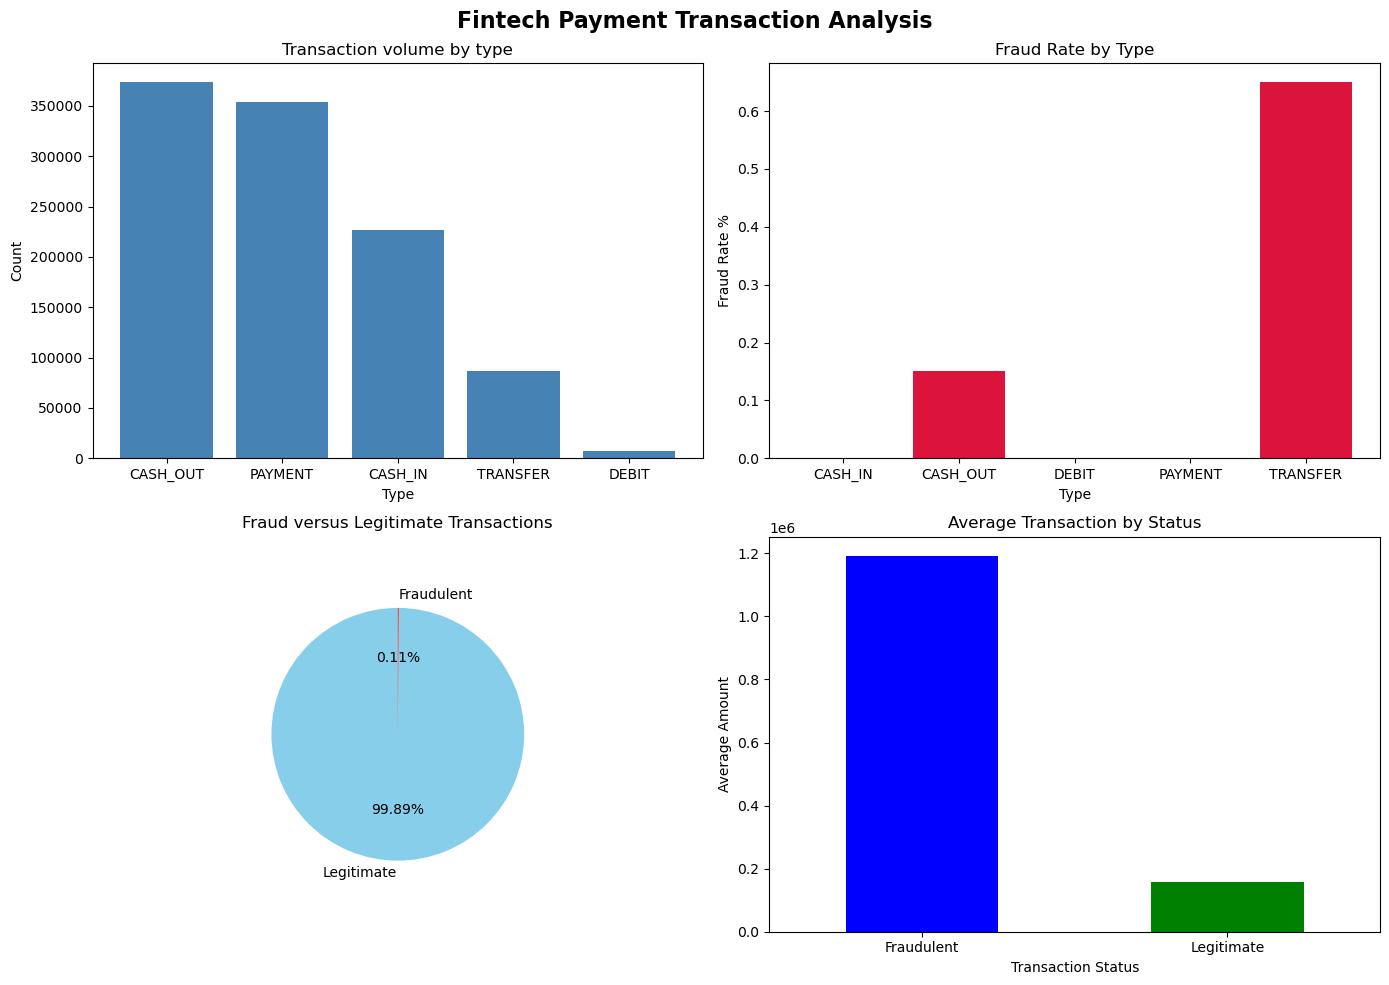

In [43]:
fig, axes = plt.subplots(2,2, figsize =(14,10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('Fintech Payment Transaction Analysis', fontsize = 16, fontweight = 'bold')

# 1st chart: Transaction volume by type
axes[0,0].bar(transaction_volume['Transaction_type'], transaction_volume ['Count'], color = 'steelblue')
axes[0,0].set_title('Transaction volume by type')
axes[0,0].set_xlabel('Type')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation = 0)

#2nd chart: Fraud Rate by Type
axes[0,1].bar(fraud_by_type['Transaction Type'], fraud_by_type['Fraud Rate %'], color='crimson')
axes[0,1].set_title('Fraud Rate by Type')
axes[0,1].set_xlabel('Type')
axes[0,1].set_ylabel('Fraud Rate %')
axes[0,1].tick_params(axis = 'x', rotation = 0)

#3rd chart: Fraud versus Legitimate count
status_count = df['Transaction Status'].value_counts()
axes[1,0].pie(status_count, labels= ['Legitimate', 'Fraudulent'],autopct = '%1.2f%%', startangle = 90,colors = ['skyblue', 'red'], radius = 0.8)
axes[1,0].set_aspect('equal')
axes[1,0].set_title('Fraud versus Legitimate Transactions')


#4th chart: Amount distribution by status
df.groupby('Transaction Status')['amount'].mean().plot(
    kind = 'bar', ax=axes[1,1],color = ['blue','green'])
axes[1,1].set_title('Average Transaction by Status')
axes[1,1].set_ylabel('Average Amount')
axes[1,1].tick_params(axis = 'x', rotation = 0)

plt.tight_layout()
plt.savefig('Payment_Analysis_Charts.png',dpi = 150)
plt.show()

In [69]:
#summary table : fraud by type
summary1 = df.groupby('type').agg(Total_Transactions = ('type', 'count'),
                                Total_fraud = ('isFraud', 'sum'),
                                Total_amount =('amount', 'sum'),
                                Average_amount = ('amount', 'mean')).reset_index()
summary1['Fraud Rate %'] = (summary1['Total_fraud']/summary1['Total_Transactions'] * 100).round(2)

#summary2 - hourly trend
df['hour'] = df['step'] % 24
hourly = df.groupby('hour').agg(
    Total_transactions =('hour','count'),
    Total_Fraud=('isFraud', 'sum')).reset_index()
hourly['Fraud Rate %'] = (hourly['Total_Fraud']/hourly['Total_transactions'] * 100).round(2)

with pd.ExcelWriter('payment_analysis_output.xlsx')as writer:
    summary1.to_excel(writer, sheet_name='Fraud by Type', index= False)
    hourly.to_excel(writer, sheet_name = 'Hourly Trends', index = False)
    df.head(10000).to_excel(writer, sheet_name ='Raw Sample', index = False)
    
print("Excel file exported successfully")

Excel file exported successfully
